In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd
import numpy as np
import torch
import torch.optim as optim
from sympy.stats.sampling.sample_scipy import scipy
from scipy.optimize import differential_evolution as de
from variables import *
from ref import *
from read_complex_matrix import read_complex_matrix
from calculating_dynamic_resolution import *
torch.set_printoptions(precision=4)

import plotly.io as pio
pio.renderers.default = "notebook"

device = torch.device('cpu')

In [2]:
from add_roughness import *

z_grid_init = np.load("z_grid_init.npy")
profile_sld_re_init = np.load("profile_sld_re_init.npy")

def plot_density_profile_1(matr):
    matrix = matr.clone()
    depth_bins = torch.cumsum((1.e+0) * matrix[:, 0].real, dim=0)
    U = (1.e-0) * matrix[:, 1].real

    x_fill = torch.cat((torch.tensor([0.0]), torch.repeat_interleave(depth_bins, 2)[:-1]), axis=0)
    y_fill = torch.repeat_interleave(U, 2)

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=x_fill.detach().cpu().numpy(),
        y=y_fill.detach().cpu().numpy(),
        mode="lines",
        line=dict(color="darkgreen"),
        fill="tozeroy"
    ))
    fig.add_trace(go.Scatter(
        x=z_grid_init+15,
        y=profile_sld_re_init,
        mode="lines",
        line=dict(color="blue")
    ))

    fig.update_xaxes(title_text='Глубина, Å')
    fig.update_yaxes(title_text='Плотность длины рассеяния, 10⁻⁶ Å⁻²')
    fig.update_layout(plot_bgcolor='white')

    return fig

plot_density_profile_1(transform_array(matr, rough_res))

In [3]:
import plotly.graph_objects as go
R_sav = np.load("R_in_savch.npy")
q_sav = np.load("q_in_savch.npy")

q = (torch.pi*4.0e+10*torch.sin(torch.tensor(np.deg2rad(data[:, 0])))/1.524-0.00207903*1.0e+10)
r_mod, r_mod_conv= reflectometry(q, matr, 0.001*sigma, 0.001*sigma, I0, Ibkg)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=q.cpu().detach().numpy()*1e-10,
    y=r0.real,
    mode='lines',
    line=dict(color='purple', width=2, dash='solid'),
    name='эксперимент'
))

fig.add_trace(go.Scatter(
    x=q.cpu().detach().numpy()[0:len(r_mod.tolist())]*1e-10,
    y=(I0*r_mod).real.tolist(),
    mode='lines',
    line=dict(color='blue', width=2, dash='solid'),
    name='расчёт'
))

fig.update_layout(
    yaxis_type="log",
    xaxis_title='q, Å',
    yaxis_title='I',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()

r = torch.tensor(r0/I0.cpu().detach().numpy())

In [4]:
from optimizer import *
from objective_function import *
loss_function = Comparator(q, r)

In [5]:
from variables import *
x_d = initial_d.reshape(-1, 5)[:, 0:2].flatten()

In [6]:
objective_function1 = loss_function.compare
loss1 = objective_function1(matr, sigma1, sigma2, I0, Ibkg, ref_type='model')

loss1

tensor(6.7901, dtype=torch.float64, grad_fn=<SelectBackward0>)

Optimizing:  99%|████████████████████████████████████████████████████████▍| 99/100 [01:29<00:00,  1.09it/s, lr=1.93e-01]C:\Users\ya\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning:

Casting complex values to real discards the imaginary part

C:\Users\ya\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning:

Casting complex values to real discards the imaginary part



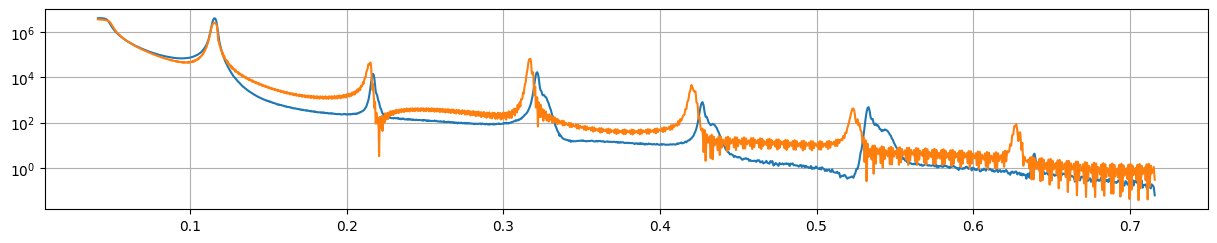

Optimizing: 100%|████████████████████████████████████████████████████████| 100/100 [01:31<00:00,  1.09it/s, lr=1.93e-01]


Stage 1: Learning Rate=0.1, Iterations=100, relative_loss=0.13313433607294387


Optimizing: 100%|███████████████████████████████████████████████████████▉| 599/600 [09:28<00:00,  1.05it/s, lr=3.08e-02]

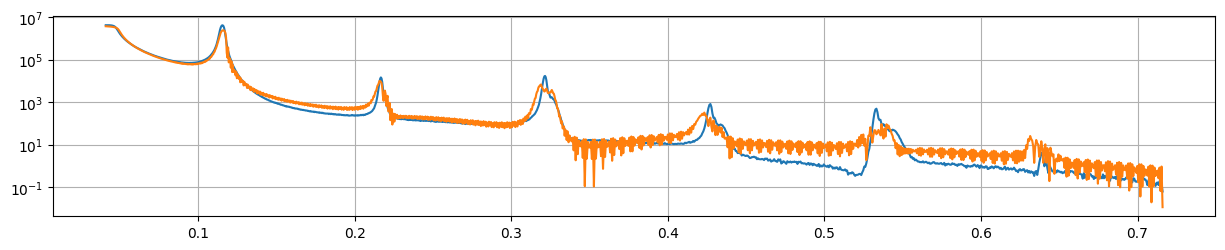

Optimizing: 100%|████████████████████████████████████████████████████████| 600/600 [09:29<00:00,  1.05it/s, lr=3.08e-02]


Stage 2: Learning Rate=0.02, Iterations=600, relative_loss=0.04255461576964777


Optimizing: 100%|███████████████████████████████████████████████████████▉| 599/600 [09:26<00:00,  1.03it/s, lr=1.54e-02]

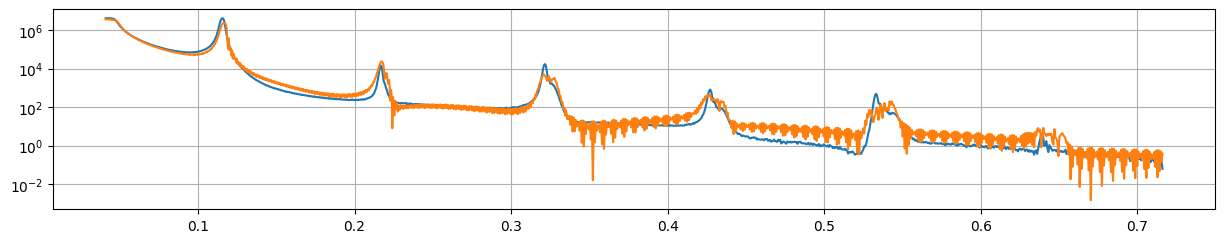

Optimizing: 100%|████████████████████████████████████████████████████████| 600/600 [09:28<00:00,  1.06it/s, lr=1.54e-02]


Stage 3: Learning Rate=0.01, Iterations=600, relative_loss=2.362854414502086


Optimizing: 100%|███████████████████████████████████████████████████████▉| 599/600 [09:04<00:00,  1.08it/s, lr=4.62e-03]

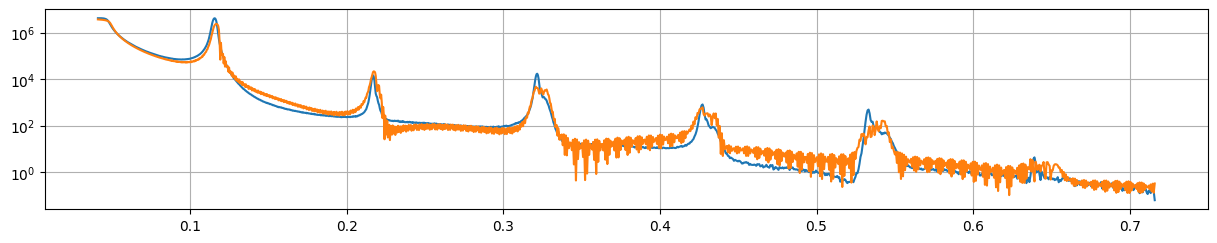

Optimizing: 100%|████████████████████████████████████████████████████████| 600/600 [09:05<00:00,  1.10it/s, lr=4.62e-03]


Stage 4: Learning Rate=0.003, Iterations=600, relative_loss=0.030907772550914165


Optimizing: 100%|█████████████████████████████████████████████████████▉| 1199/1200 [18:07<00:00,  1.06it/s, lr=2.35e-03]

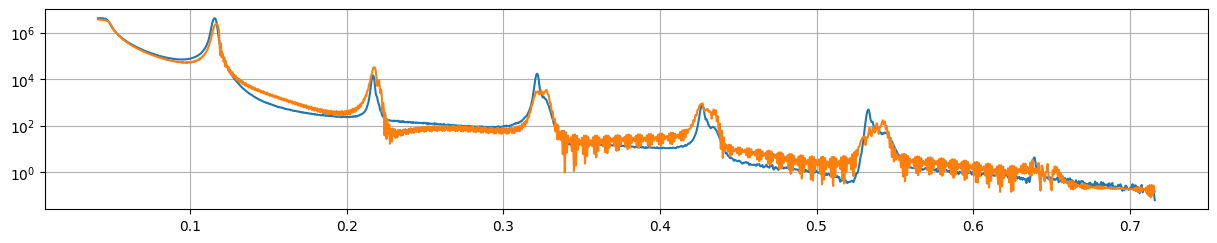

Optimizing: 100%|██████████████████████████████████████████████████████| 1200/1200 [18:08<00:00,  1.10it/s, lr=2.35e-03]


Stage 5: Learning Rate=0.002, Iterations=1200, relative_loss=0.6685102921320879


In [7]:
loss_classes = [
    varbounds(all_bounds, loss_function.compare, 0.4, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_08, 0.4, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_05, 0.2, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_025, 0.1, matr, sigma1, sigma2, I0, Ibkg, ref_type='model'),
    varbounds(all_bounds, loss_function.compare_weightless, 0.06, matr, sigma1, sigma2, I0, Ibkg, ref_type='model')
]

learning_rates = [0.1, 0.02, 0.01, 0.003, 0.002]
iterations = [100, 600, 600, 600, 1200]
#betas=(0.9655, 0.99)

ans_d, ans_r_rho, ans_i_rho, ans_I, ans_Ibkg, loss, rel_losses = pie_optimizer(q, r, (0.9655, 0.99),    0.991,
 0.004,
    learning_rates,
    iterations,
    loss_classes
)

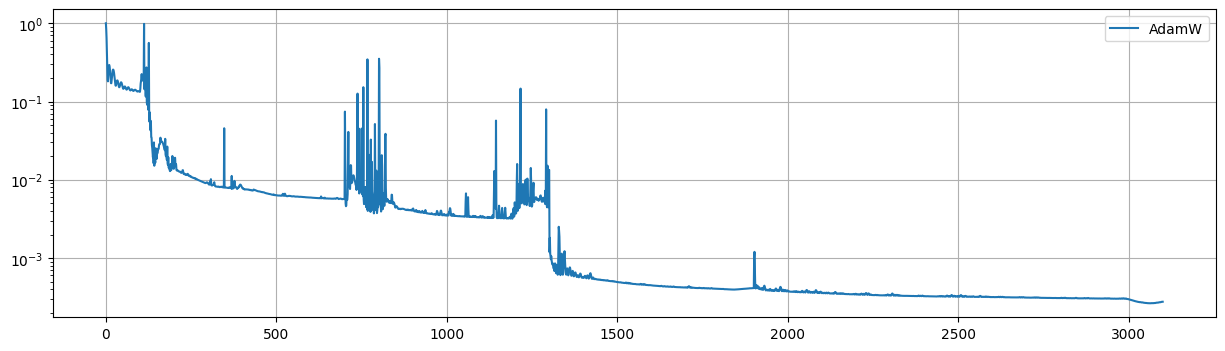

In [8]:
fig, ax = plt.subplots(figsize =(15, 4))

ax.plot(range(0,len(rel_losses)), rel_losses, label='AdamW')

ax.set_yscale('log')
ax.legend()
plt.grid()
plt.show()

In [9]:
combined_x_for_print = torch.cat((ans_d.reshape(-1, 5), torch.complex(ans_r_rho, ans_i_rho).reshape(-1, 1)), dim=1)[:,
                       torch.tensor([0, 5, 1, 2, 3, 4])]
r_mod, r_mod_conv= reflectometry(q, torch.cat((matr[0,:].reshape(-1, 6), combined_x_for_print.reshape(-1, 6)), axis= 0), 0.001*sigma, 0.001*sigma, I0, Ibkg)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=q.cpu().detach().numpy()*1e-10,
    y=r0.real,
    mode='lines',
    line=dict(color='purple', width=2, dash='solid'),
    name='эксперимент'
))

fig.add_trace(go.Scatter(
    x=q.cpu().detach().numpy()[0:len(r_mod.tolist())]*1e-10,
    y=(I0*r_mod).real.tolist(),
    mode='lines',
    line=dict(color='blue', width=2, dash='solid'),
    name='расчёт'
))

fig.update_layout(
    yaxis_type="log",
    xaxis_title='q, Å',
    yaxis_title='I',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()

In [10]:
combined_x_for_print = torch.cat((ans_d.reshape(-1, 5), torch.complex(ans_r_rho, ans_i_rho).reshape(-1, 1)), dim=1)[:,torch.tensor([0, 5, 1, 2,3,4])]
fig = plot_density_profile(transform_array(torch.cat((matr[0,:].reshape(-1, 6), combined_x_for_print.reshape(-1, 6)), axis= 0), rough_res))
fig.show()

In [11]:
#np_bounds = all_bounds[1:,[0,2],:].reshape(-1, 2).detach().numpy()
np_bounds = np.array([
    [15.0, 90.0], [6.0, 90.0],
    [20.0, 90.0], [6.0, 80.0],
    [15.0, 90.0], [6.0, 90.0],
    [20.0, 90.0], [6.0, 80.0]
])

var_vector = combined_x_for_print.real[2:-1, [0,2]].flatten().detach().numpy()

n_walkers = 24

sc = 0.001
sc_add = 0.0001

position = np.transpose(np.repeat(var_vector.reshape(-1, 1), n_walkers, axis = 1))

position+=position*(sc*np.random.rand(n_walkers, var_vector.shape[0])-sc/2)+(sc_add*np.random.rand(n_walkers, var_vector.shape[0])-sc_add/2)

vv = torch.tensor(var_vector)

In [12]:
torch.cat((ans_d.reshape(-1,5)[[0,1], 0:2], vv.reshape(-1,2), ans_d.reshape(-1,5)[[-1], 0:2]), dim=0)

tensor([[31.5377, 20.7625],
        [31.2796, 16.8927],
        [25.3558, 22.1918],
        [34.5094, 23.4592],
        [24.3094, 20.2354],
        [33.3981, 21.5785],
        [99.9900,  2.9553]])

In [13]:
torch.cat((torch.cat((ans_d.reshape(-1,5)[[0,1], 0:2], vv.reshape(-1,2), ans_d.reshape(-1,5)[[-1], 0:2]), dim=0), torch.complex(ans_r_rho, ans_i_rho).reshape(-1, 1), ans_d.reshape(-1,5)[:, [2,3,4]]), dim=1)[:, [0,2,1,3,4,5]]

tensor([[3.1538e+01+0.0000j, 6.4400e+01-1.3484j, 2.0762e+01+0.0000j,
         2.4709e-01+0.0000j, 4.8104e-01+0.0000j, 5.7673e-01+0.0000j],
        [3.1280e+01+0.0000j, 3.5798e+01-3.0109j, 1.6893e+01+0.0000j,
         4.4186e-04+0.0000j, 1.0005e-01+0.0000j, 8.4146e-01+0.0000j],
        [2.5356e+01+0.0000j, 6.4400e+01-1.3484j, 2.2192e+01+0.0000j,
         1.8671e-02+0.0000j, 5.5128e-01+0.0000j, 7.7106e-01+0.0000j],
        [3.4509e+01+0.0000j, 3.5798e+01-3.0109j, 2.3459e+01+0.0000j,
         3.6085e-01+0.0000j, 3.3659e-01+0.0000j, 8.0615e-01+0.0000j],
        [2.4309e+01+0.0000j, 6.4400e+01-1.3484j, 2.0235e+01+0.0000j,
         1.3892e-01+0.0000j, 1.5475e-01+0.0000j, 9.5375e-01+0.0000j],
        [3.3398e+01+0.0000j, 3.5798e+01-3.0109j, 2.1579e+01+0.0000j,
         3.4544e-01+0.0000j, 1.6531e-01+0.0000j, 4.5321e-01+0.0000j],
        [9.9990e+01+0.0000j, 2.0072e+01-0.8702j, 2.9553e+00+0.0000j,
         6.4746e-01+0.0000j, 7.5370e-01+0.0000j, 7.0079e-01+0.0000j]])

In [14]:
from calculating_dynamic_resolution import resolution_function_smooth_step
sigmas = []
for q_i in q:
    sigmas.append(resolution_function_smooth_step(q[-1], q_i, sigma1, sigma2, gap).cpu().detach().numpy())
sigmas = np.array(sigmas)

def log_likelihood(theta, I0, Ibkg, q, r_exp, sigmas=None):
    var_vector = torch.tensor(theta)
    q = q.cpu().detach().numpy()
    r_exp = r_exp.cpu().detach().numpy()

    matr_untr = torch.cat((torch.cat((ans_d.reshape(-1,5)[[0,1], 0:2], var_vector.reshape(-1,2), ans_d.reshape(-1,5)[[-1], 0:2]), dim=0), torch.complex(ans_r_rho, ans_i_rho).reshape(-1, 1), ans_d.reshape(-1,5)[:, [2,3,4]]), dim=1)[:, [0,2,1,3,4,5]]
    new_matr = torch.cat((matr[[0], :], matr_untr), dim=0)

    r_model, _ = reflectometry(q, new_matr, sigma1, sigma2, I0, Ibkg)
    if isinstance(r_model, torch.Tensor):
         r_model = r_model.real.cpu().detach().numpy()

    r_min = np.minimum(r_exp, r_model)

    return -0.5 * np.sum(((r_exp - r_model)/r_min)**2)


def log_prior(theta):
    summa = 0

    for o, x in enumerate(theta):
        if (np_bounds[o,0]> x or x > np_bounds[o,1]):
            summa+=1

    if summa>0:
        return -np.inf
    return 0



def log_probability(theta, I0, Ibkg, q, r_exp, sigmas=None):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, I0, Ibkg, q, r_exp, sigmas)

In [15]:
import emcee

nwalkers, ndim = position.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(I0, Ibkg, q, r, sigmas)
)
sampler.run_mcmc(position, 2000, progress=True);

100%|██████████| 2000/2000 [4:02:13<00:00,  7.27s/it]  


C:\Users\ya\AppData\Local\Temp\ipykernel_6400\2904339175.py:6: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.



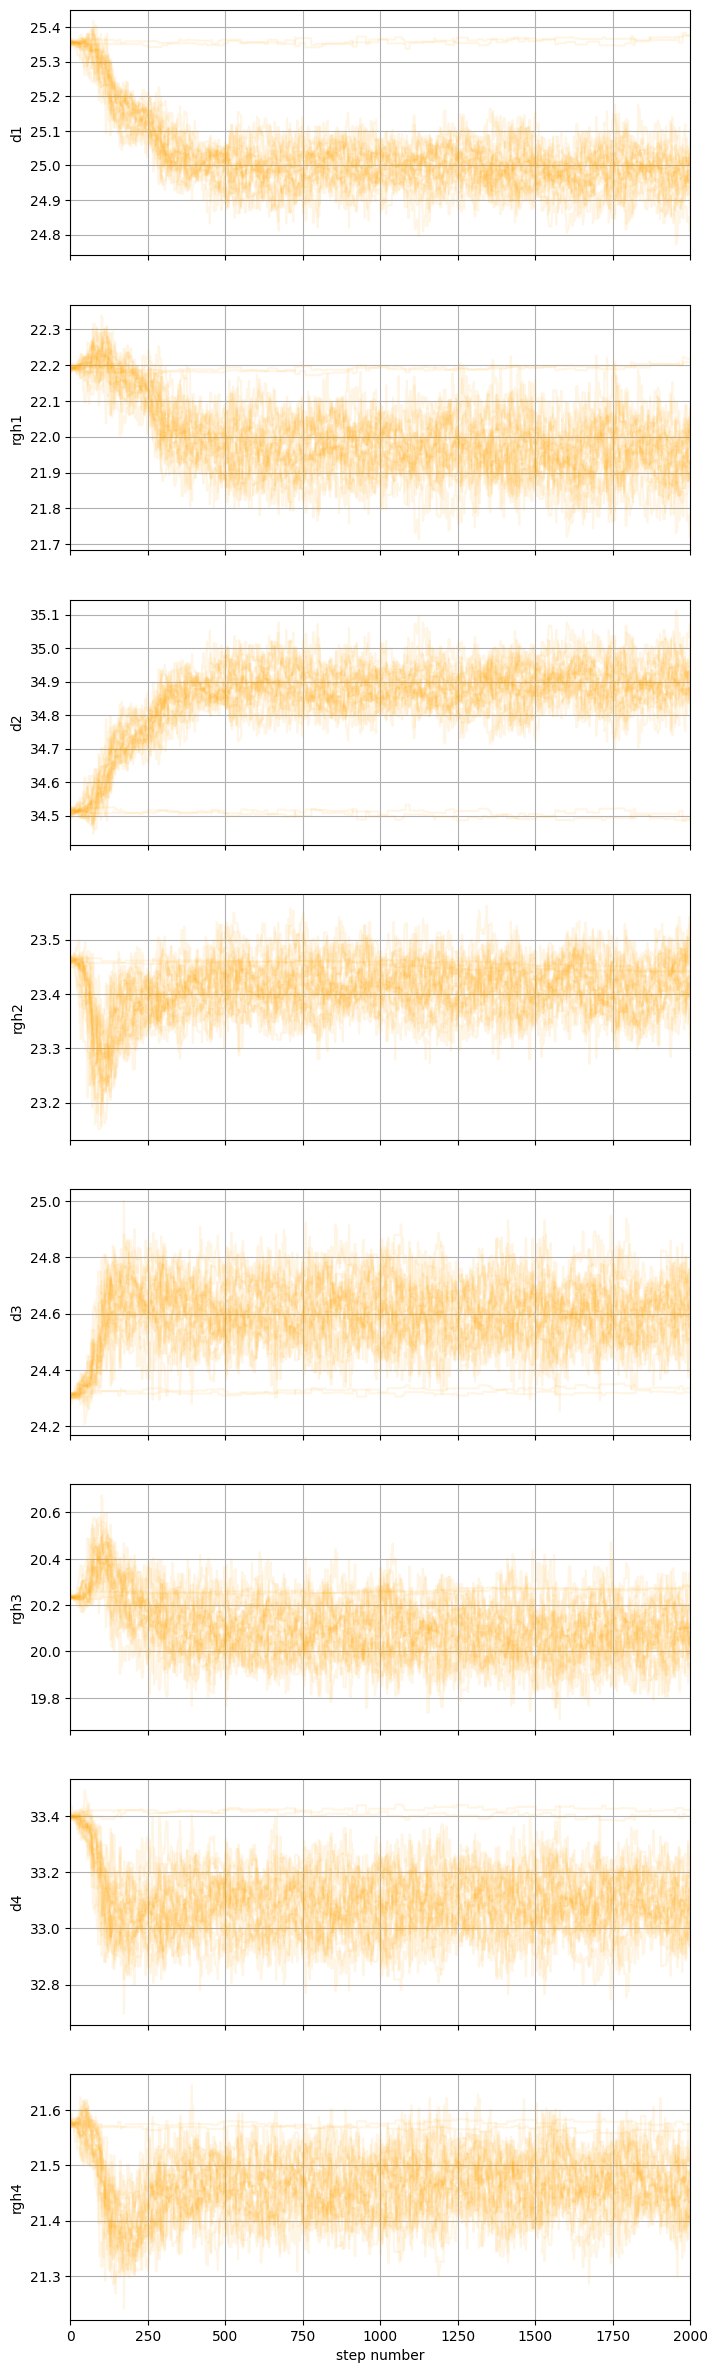

In [16]:
fig, axes = plt.subplots(8, figsize=(8, 30), sharex=True)
samples = sampler.get_chain()
labels = ["d1", "rgh1", "d2", "rgh2", "d3", "rgh3", "d4", "rgh4"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.1, color='orange')
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.grid(True)

axes[-1].set_xlabel("step number");

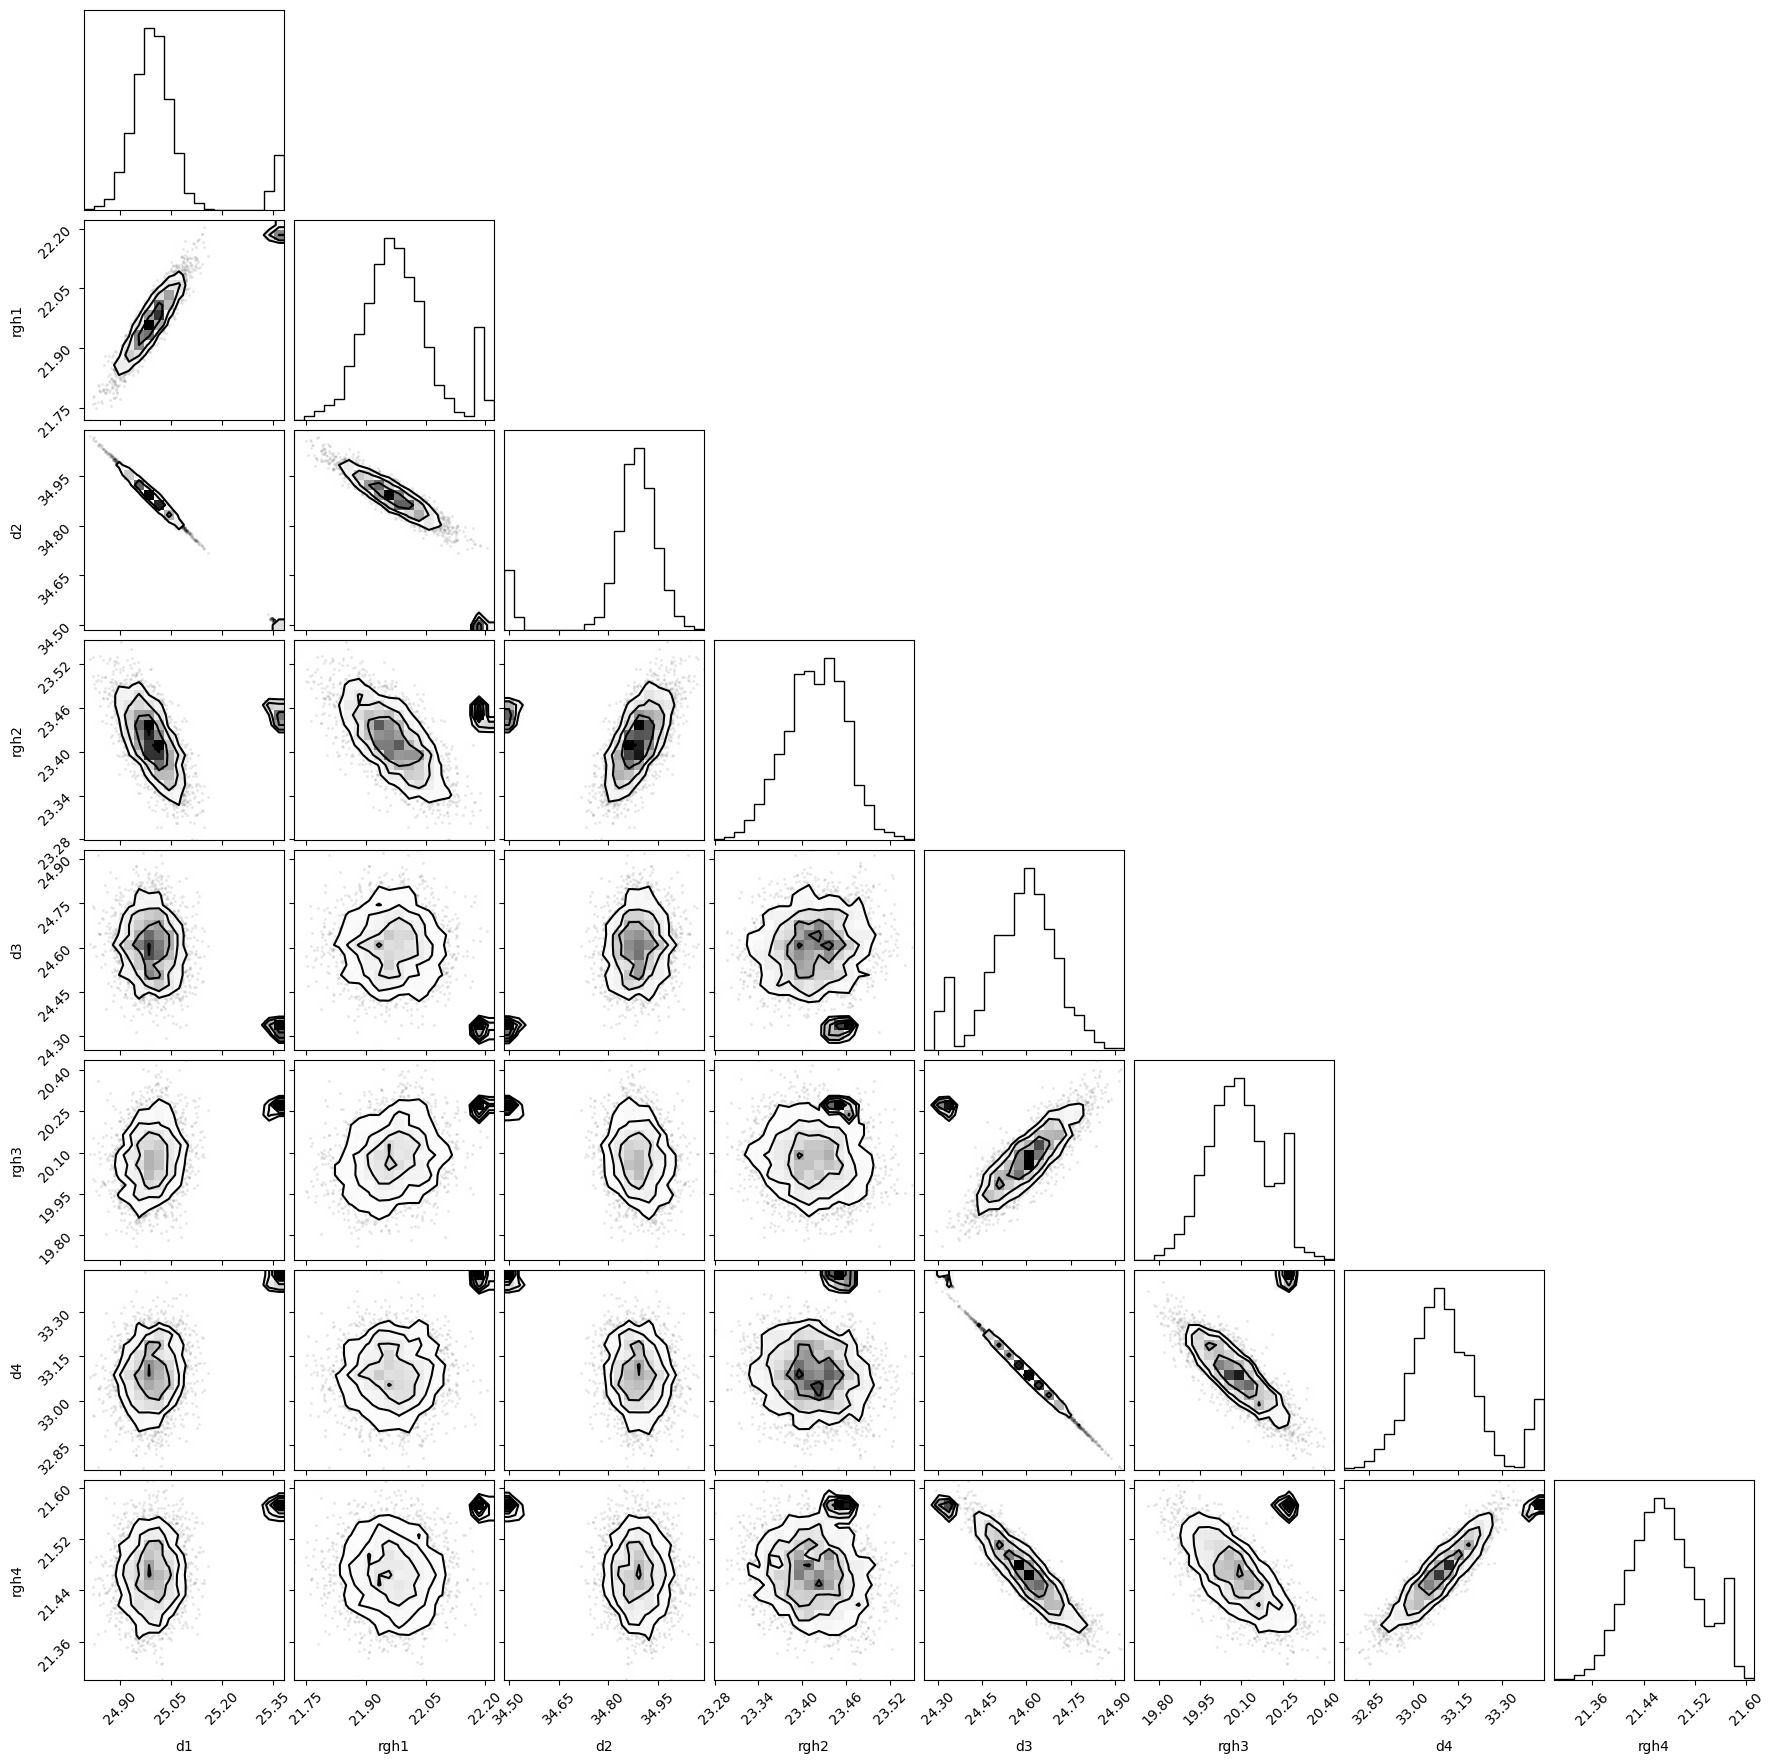

In [17]:
flat_samples = sampler.get_chain(discard=700, thin=10, flat=True)
import corner

fig = corner.corner(
    flat_samples, labels=labels
)

C:\Users\ya\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning:

Casting complex values to real discards the imaginary part

C:\Users\ya\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning:

Casting complex values to real discards the imaginary part



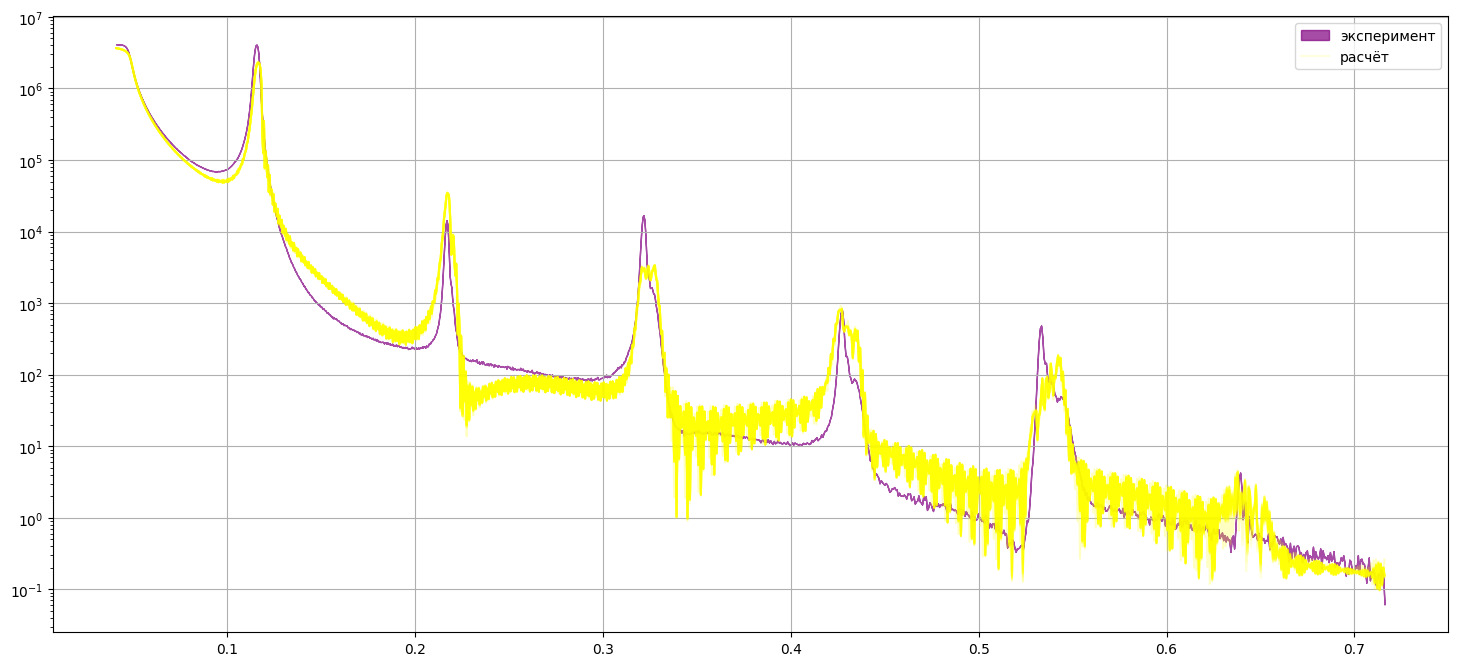

In [18]:
final_samples = samples[-1, :, :]
r_mod_list = []
matr_mod_list = []

for sample in final_samples:
    var_vector = torch.tensor(sample)

    x_matr =torch.cat((torch.cat((ans_d.reshape(-1,5)[[0,1], 0:2], var_vector.reshape(-1,2), ans_d.reshape(-1,5)[[-1], 0:2]), dim=0), torch.complex(ans_r_rho, ans_i_rho).reshape(-1, 1), ans_d.reshape(-1,5)[:, [2,3,4]]), dim=1)[:, [0,2,1,3,4,5]]
    new_matr = torch.cat((matr[[0], :], x_matr), dim=0)

    _, r_mod_conv2= reflectometry(q, new_matr, 0.001*sigma, 0.001*sigma, I0, Ibkg)
    r_mod_list.append(r_mod_conv2)
    matr_mod_list.append(transform_array(new_matr, rough_res))

fig, ax = plt.subplots(figsize=(18, 8))

# Заливка для экспериментальных данных
ax.fill_between(q*1e-10, r0, r0, color='purple', alpha=0.7, label='эксперимент')

# Отрисовка всех графиков из r_mod_list
for r_mod_conv2 in r_mod_list:
    ax.plot(q[0:len(r_mod_conv2.tolist())]*1e-10, (I0*r_mod_conv2).tolist(), color='yellow', alpha=0.13, label='расчёт' if r_mod_conv2 is r_mod_list[0] else None)

# Настройки осей и легенды
ax.set_yscale('log')
ax.legend()
plt.grid()
plt.show()

In [19]:
combined_x_for_print = torch.cat((ans_d.reshape(-1, 5), torch.complex(ans_r_rho, ans_i_rho).reshape(-1, 1)), dim=1)[:,
                       torch.tensor([0, 5, 1, 2, 3, 4])]
#r_mod, r_mod_conv= reflectometry(q, torch.cat((matr[0,:].reshape(-1, 6), combined_x_for_print.reshape(-1, 6)), axis= 0), 0.001*sigma, 0.001*sigma, I0, Ibkg)

old_matr = torch.cat((matr[0,:].reshape(-1, 6), combined_x_for_print.reshape(-1, 6)), axis=0)
old_matr.shape

torch.Size([8, 6])

In [20]:
new_matr

tensor([[1.0000e+01+0.0000j, 0.0000e+00+0.0000j, 0.0000e+00+0.0000j,
         0.0000e+00+0.0000j, 0.0000e+00+0.0000j, 0.0000e+00+0.0000j],
        [3.1538e+01+0.0000j, 6.4400e+01-1.3484j, 2.0762e+01+0.0000j,
         2.4709e-01+0.0000j, 4.8104e-01+0.0000j, 5.7673e-01+0.0000j],
        [3.1280e+01+0.0000j, 3.5798e+01-3.0109j, 1.6893e+01+0.0000j,
         4.4186e-04+0.0000j, 1.0005e-01+0.0000j, 8.4146e-01+0.0000j],
        [2.4961e+01+0.0000j, 6.4400e+01-1.3484j, 2.1901e+01+0.0000j,
         1.8671e-02+0.0000j, 5.5128e-01+0.0000j, 7.7106e-01+0.0000j],
        [3.4921e+01+0.0000j, 3.5798e+01-3.0109j, 2.3493e+01+0.0000j,
         3.6085e-01+0.0000j, 3.3659e-01+0.0000j, 8.0615e-01+0.0000j],
        [2.4509e+01+0.0000j, 6.4400e+01-1.3484j, 2.0005e+01+0.0000j,
         1.3892e-01+0.0000j, 1.5475e-01+0.0000j, 9.5375e-01+0.0000j],
        [3.3184e+01+0.0000j, 3.5798e+01-3.0109j, 2.1510e+01+0.0000j,
         3.4544e-01+0.0000j, 1.6531e-01+0.0000j, 4.5321e-01+0.0000j],
        [9.9990e+01+0.0000j

In [21]:
def plot_density_profile_variator(matr_list):
    fig = go.Figure()

    # Проходим по каждому тензору в списке
    for matr in matr_list:
        matrix = torch.tensor(matr)
        depth_bins = torch.cumsum((1.e+0) * matrix[:, 0].real, dim=0)
        U = (1.e-0) * matrix[:, 1].real

        x_fill = torch.cat((torch.tensor([0.0]), torch.repeat_interleave(depth_bins, 2)[:-1]), axis=0)
        y_fill = torch.repeat_interleave(U, 2)

        # Добавляем график с полупрозрачностью и одинаковым цветом
        fig.add_trace(go.Scatter(
            x=x_fill.detach().cpu().numpy(),
            y=y_fill.detach().cpu().numpy(),
            mode="lines",
            line=dict(color="darkgreen"),
            opacity=0.8,  # Полупрозрачность
            showlegend=(matr is matr_list[0])  # Показываем легенду только для первого графика
        ))

    # Настройки осей и макета
    fig.update_xaxes(title_text='Глубина, Å')
    fig.update_yaxes(title_text='Плотность длины рассеяния, 10⁻⁶ Å⁻²')
    fig.update_layout(plot_bgcolor='white')

    return fig

fig = plot_density_profile_variator(matr_mod_list)
fig.show()

C:\Users\ya\AppData\Local\Temp\ipykernel_6400\414039210.py:6: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).

